In [1]:
!sudo apt-get update -qq
!sudo apt-get install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-lato fonts-lmodern fonts-texgyre
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern pfb2t1c2pfb preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  libavalon-framework-java libcommons-loggin

In [3]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import warnings
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from __future__ import annotations
import os, re, math
from typing import Iterable, Set, Dict, Tuple, Sequence, List
from polars import selectors as cs
import polars as pl
from itertools import combinations
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.cm as cm
from scipy.stats import spearmanr
from matplotlib_venn import venn3
from matplotlib.patches import Patch

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

%config HistoryManager.enabled = False
warnings.filterwarnings('ignore')


In [4]:
# THESIS STYLE FOR PLOT
def apply_thesis_style(use_tex: bool = True,
                       legend_position: str = "upper right",
                       legend_outside: bool = False):
    """
    Applies a uniform style (Matplotlib + Seaborn) consistent with LaTeX
    and defines `place_legend()` to position legends consistently.

    Parameters
    ----------
    use_tex : bool
        If True, enables LaTeX text rendering (requires TeX installed).
    legend_position : str
        DEFAULT position for legends: 'upper right', 'upper left',
        'lower right', 'lower left', 'center', 'best' (also accepts 'top/bottom').
    legend_outside : bool
        If True, the default legend is outside the plot (to the right).
    """

    # --- Normalize default position ---
    def _normalize_pos(pos: str) -> str:
        if not isinstance(pos, str):
            return "upper right"
        key = pos.strip().lower().replace("top", "upper").replace("bottom", "lower")
        mapping = {
            "upper right": "upper right",
            "upper left":  "upper left",
            "lower right": "lower right",
            "lower left":  "lower left",
            "center":      "center",
            "best":        "best",
        }
        return mapping.get(key, "upper right")

    _default_loc = _normalize_pos(legend_position)

    # --- Seaborn theme + rcParams consistent with thesis ---
    sns.set_theme(style="whitegrid", context="notebook")
    mpl.rcParams.update({
        # Typography
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Latin Modern Roman", "Times New Roman"],
        "mathtext.fontset": "cm",
        "text.usetex": bool(use_tex),

        # Sizes
        "figure.figsize": (6.8, 4.5),
        "font.size": 8.5,          # generic text (plt.text, etc.)
        "axes.labelsize": 10.5,    # axis labels
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9.5,
        "legend.title_fontsize": 9.5,

        # Axes look
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.facecolor": "white",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,

        # Legend style (default; can be overridden by place_legend)
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#D0D0D0",
        "legend.loc": _default_loc,
        "legend.framealpha": 1.0,
        "legend.handlelength": 1.8,
        "legend.handletextpad": 0.6,
        "legend.borderpad": 0.4,
        "legend.borderaxespad": 0.8,
    })

    def place_legend(ax=None,
                     position: str | None = None,
                     outside: bool | None = None,
                     fontsize: float | None = None):
        """
        Places the legend on an axis with consistent thesis style.

        Parameters
        ----------
        ax : matplotlib.axes.Axes, optional
            Axis on which to place the legend (default: current axis).
        position : str | None
            'upper right', 'upper left', 'lower right', 'lower left', 'center', 'best'.
            If None, uses the default position passed to apply_thesis_style().
            Spaces/caps tolerated; 'top/bottom' mapped to 'upper/lower'.
        outside : bool | None
            If True, places the legend outside the plot (to the right).
            If None, uses the default value passed to apply_thesis_style().
        fontsize : float | None
            To change the legend font size only in this plot.
        """

        if ax is None:
            ax = plt.gca()

        # Normalize requested position or use global default
        loc_val = _default_loc
        if isinstance(position, str):
            key = position.strip().lower().replace("top", "upper").replace("bottom", "lower")
            loc_map = {
                "upper right": "upper right",
                "upper left":  "upper left",
                "lower right": "lower right",
                "lower left":  "lower left",
                "center":      "center",
                "best":        "best",
            }
            loc_val = loc_map.get(key, _default_loc)

        # outside: if None, inherit from default; otherwise use override
        outside = (legend_outside if outside is None else bool(outside))

        # Build kwargs consistent with rcParams
        legend_kwargs = dict(
            loc=loc_val,
            frameon=True,
            facecolor="white",
            edgecolor=mpl.rcParams["legend.edgecolor"],
            framealpha=1.0,
            fontsize=mpl.rcParams["legend.fontsize"] if fontsize is None else fontsize,
            handlelength=1.8,
            handletextpad=0.6,
            borderpad=0.4,
            fancybox=False,
        )

        if outside:
            legend_kwargs.update({
                "bbox_to_anchor": (1.02, 1.0),
                "borderaxespad": 0.0,
            })

        leg = ax.legend(**legend_kwargs)
        if leg is not None:
            leg.get_frame().set_linewidth(0.8)
            leg.get_frame().set_edgecolor(mpl.rcParams["legend.edgecolor"])
            leg.get_frame().set_facecolor("white")
        return ax

    # Export the helper to the global notebook/script namespace
    globals()["place_legend"] = place_legend
    

In [5]:
# ============================================================
# STEP 0–1 — LOAD → filter labels {0,1} → drop blacklist CpGs
#          → split 0.8/0.2 stratified → Edgar(β) on TRAIN only
#          → apply Edgar-selected CpGs to TRAIN+TEST (no leakage)
# ============================================================

import numpy as np
import polars as pl
from sklearn.model_selection import train_test_split

# -----------------------------
# CONFIG (edit only these)
# -----------------------------
BETA_PATH = "/kaggle/input/datasets/rovieramariella/gse225845-parquet/GSE225845.parquet"

BLACKLIST_PATH = "/kaggle/input/datasets/rovieramariella/removed-cpgs-all-filters-summary-gse225845/removed_cpgs_all_filters_summary_gse225845.csv"
BLACKLIST_CPG_COL = "CpG_ID"

ID_COL = "id_tissue"
LABEL_COL = "label"
LABELS_USE = [0, 1]

TEST_SIZE = 0.20
RANDOM_STATE = 42

# Edgar (β)
R_BETA_CUTOFF = 0.05

# -----------------------------
# HELPERS
# -----------------------------
def compute_r_beta_edgar(beta_df: pl.DataFrame, label_col: str, label_values, cpg_cols):
    """
    Edgar-like variability: r_beta = Q90 - Q10 computed on subset with label in label_values.
    """
    subset = beta_df.filter(pl.col(label_col).is_in(label_values))
    subset_cpg = subset.select(cpg_cols)
    q90 = subset_cpg.select(pl.all().quantile(0.90)).to_numpy()[0, :]
    q10 = subset_cpg.select(pl.all().quantile(0.10)).to_numpy()[0, :]
    return q90 - q10

# -----------------------------
# STEP 0 — LOAD + FILTER LABELS + DROP BLACKLIST CpGs
# -----------------------------
print("=" * 90)
print("STEP 0 — LOAD + filter labels {0,1} + drop blacklist CpGs")
print("=" * 90)

# blacklist CpGs
bl = pl.read_csv(BLACKLIST_PATH)
black_cpgs_set = set(
    bl.select(pl.col(BLACKLIST_CPG_COL).cast(pl.Utf8)).unique().to_series().to_list()
)
print(f"Blacklist CpGs: {len(black_cpgs_set):,}")

# load beta parquet
beta = (
    pl.read_parquet(BETA_PATH)
    .filter(pl.col(LABEL_COL).is_in(LABELS_USE))
    .with_columns([
        pl.col(ID_COL).cast(pl.Utf8),
        pl.col(LABEL_COL).cast(pl.Int64),
    ])
)

# CpG columns: keep only cg/ch + ID/LABEL
cpg_cols_all = [c for c in beta.columns if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
cpg_cols_set = set(cpg_cols_all)

# drop blacklist CpGs
to_drop_blacklist = [c for c in cpg_cols_all if c in black_cpgs_set]

# drop any other unexpected string columns (safety, keeps only ID, LABEL, CpGs)
to_drop_other = [
    c for c in beta.columns
    if isinstance(c, str) and (c not in cpg_cols_set) and (c not in (ID_COL, LABEL_COL))
]

beta = beta.drop(to_drop_blacklist + to_drop_other)

print(f"After label filter + drops: shape={beta.shape}")
print(f"CpGs kept (pre-split): {len([c for c in beta.columns if isinstance(c, str) and (c.startswith('cg') or c.startswith('ch'))]):,}")

# -----------------------------
# STEP 1 — SPLIT + EDGAR TRAIN-ONLY + APPLY TO BOTH
# -----------------------------
print("\n" + "=" * 90)
print("STEP 1 — split 0.8/0.2 stratified + Edgar(β) train-only + apply CpGs to train/test")
print("=" * 90)

y_all = beta.select(LABEL_COL).to_numpy().ravel().astype(int)
idx_all = np.arange(beta.height)

tr_idx, te_idx = train_test_split(
    idx_all,
    test_size=TEST_SIZE,
    stratify=y_all,
    random_state=RANDOM_STATE
)

# build split frames without copying CpG matrices yet
beta_idx = beta.with_row_count("_row_id")
beta_tr = beta_idx.filter(pl.col("_row_id").is_in(tr_idx.tolist())).drop("_row_id")
beta_te = beta_idx.filter(pl.col("_row_id").is_in(te_idx.tolist())).drop("_row_id")

print(f"Split sizes: train={beta_tr.height} | test={beta_te.height}")

# Edgar on TRAIN ONLY
cpg_cols_train = [c for c in beta_tr.columns if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
r_beta = compute_r_beta_edgar(beta_tr, LABEL_COL, LABELS_USE, cpg_cols_train)

mask_keep = r_beta >= R_BETA_CUTOFF
cpg_cols_edgar = [cpg_cols_train[i] for i in range(len(cpg_cols_train)) if mask_keep[i]]

print(f"Edgar cutoff r_beta >= {R_BETA_CUTOFF}")
print(f"CpGs before Edgar: {len(cpg_cols_train):,}")
print(f"CpGs after  Edgar: {len(cpg_cols_edgar):,}  (dropped {len(cpg_cols_train) - len(cpg_cols_edgar):,})")

# Apply Edgar-selected CpGs to BOTH train and test (no leakage)
beta_tr = beta_tr.select([ID_COL, LABEL_COL] + cpg_cols_edgar)
beta_te = beta_te.select([ID_COL, LABEL_COL] + cpg_cols_edgar)

# Optionally expose matrices
B_train = beta_tr.select(cpg_cols_edgar).to_numpy().astype(np.float32)
B_test  = beta_te.select(cpg_cols_edgar).to_numpy().astype(np.float32)
y_train = beta_tr.select(LABEL_COL).to_numpy().ravel().astype(int)
y_test  = beta_te.select(LABEL_COL).to_numpy().ravel().astype(int)

print(f"Final matrices: B_train={B_train.shape} | B_test={B_test.shape}")
print("Done.")


STEP 0 — LOAD + filter labels {0,1} + drop blacklist CpGs
Blacklist CpGs: 219,743
After label filter + drops: shape=(253, 530685)
CpGs kept (pre-split): 530,683

STEP 1 — split 0.8/0.2 stratified + Edgar(β) train-only + apply CpGs to train/test
Split sizes: train=202 | test=51
Edgar cutoff r_beta >= 0.05
CpGs before Edgar: 530,683
CpGs after  Edgar: 396,644  (dropped 134,039)
Final matrices: B_train=(202, 396644) | B_test=(51, 396644)
Done.



Edgar(β) variability on TRAIN — Q90−Q10 distribution with 3 cutoffs

Saved plot to: plots_outputs/GSE225845_edgar_variability.pdf


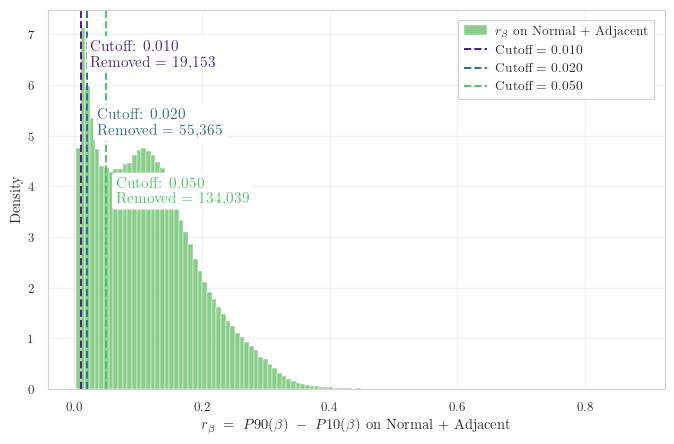

In [7]:
# -----------------------------
# PLOT — Edgar(β) variability (train-only) — white background only (no border)
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nEdgar(β) variability on TRAIN — Q90−Q10 distribution with 3 cutoffs\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

r_beta = np.asarray(r_beta, dtype=float)

cutoffs = [0.010, 0.020, 0.050]

HIST_COLOR = "#7FC97F"

LINE_COLORS = {
    0.010: plt.cm.viridis(0.10),
    0.020: plt.cm.viridis(0.35),
    0.050: plt.cm.viridis(0.72),
}

HIST_LABEL = r"$r_\beta$ on Normal + Adjacent"
XLABEL = r"$r_\beta \;=\; P90(\beta)\;-\;P10(\beta)$ on Normal + Adjacent"

fig, ax = plt.subplots()

ax.hist(
    r_beta,
    bins=120,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label=HIST_LABEL,
    zorder=1,
)

ymax = ax.get_ylim()[1]
X_SHIFT = 0.015

for i, c in enumerate(cutoffs):
    col = LINE_COLORS[c]

    ax.axvline(
        c,
        linestyle="--",
        linewidth=1.4,
        color=col,
        label=rf"Cutoff = {c:0.3f}",
        zorder=2,
    )

    removed = int((r_beta < c).sum())

    ax.text(
        c + X_SHIFT,
        ymax * (0.92 - 0.18 * i),
        f"Cutoff: {c:0.3f}\nRemoved = {removed:,}",
        color=col,
        fontsize=11.0,
        fontweight="semibold",
        ha="left",
        va="top",
        zorder=5,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            linewidth=0,
            alpha=1.0,
        ),
    )

ax.set_xlabel(XLABEL)
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF) — after fig exists
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / "GSE225845_edgar_variability.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()


In [8]:
# -----------------------------
# STEP 2 — M-transform + variance filter (train-only)
#   - beta -> M (post-Edgar)
#   - drop lowest-variance 2% in TRAIN only (optional/off if Edgar is aggressive)
# -----------------------------

# CONFIG (add/override)
EPS_M = 1e-6
VAR_DROP_FRAC = 0.02          # drop lowest 2% by variance/SD
APPLY_VAR_FILTER = True       # set False if Edgar already aggressive

def beta_to_m(beta_arr: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def soft_sd_filter(X, cols, drop_frac):
    sd = X.std(axis=0, ddof=1)
    thr = np.quantile(sd, drop_frac)
    keep = sd >= thr
    return X[:, keep], cols[keep], sd[keep], keep

print("\n" + "=" * 90)
print("STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only")
print("=" * 90)

# (assumes from STEP 1 you have: B_train, B_test, beta_tr, beta_te, cpg_cols_edgar)
cols_full = np.array(cpg_cols_edgar, dtype=object)

# β → M
M_train = beta_to_m(B_train, eps=EPS_M).astype(np.float32)
M_test  = beta_to_m(B_test,  eps=EPS_M).astype(np.float32)
print(f"After M-transform: M_train={M_train.shape} | M_test={M_test.shape}")

# Variance/SD filter (train-only), optional
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    M_train_f, cols_f, sd_f, keep_mask = soft_sd_filter(M_train, cols_full, drop_frac=VAR_DROP_FRAC)
    M_test_f = M_test[:, keep_mask]

    print(f"Variance filter: drop_frac={VAR_DROP_FRAC:.2%}")
    print(f"CpGs before: {M_train.shape[1]:,} | after: {M_train_f.shape[1]:,}  (dropped {M_train.shape[1]-M_train_f.shape[1]:,})")

    # overwrite "current" matrices/cols for next steps
    M_train, M_test, cols_full = M_train_f, M_test_f, cols_f
else:
    print("Variance filter OFF (no CpGs removed).")

# keep aligned beta matrices too (needed later for |Δβ| gates)
# B_train/B_test remain post-Edgar; apply same keep_mask if variance filter ON
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    B_train = B_train[:, keep_mask]
    B_test  = B_test[:, keep_mask]
    cpg_cols_current = cols_full.copy()
else:
    cpg_cols_current = cols_full.copy()

print(f"Current aligned: B_train={B_train.shape} | M_train={M_train.shape} | CpGs={len(cpg_cols_current):,}")



STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only
After M-transform: M_train=(202, 396644) | M_test=(51, 396644)
Variance filter: drop_frac=2.00%
CpGs before: 396,644 | after: 388,711  (dropped 7,933)
Current aligned: B_train=(202, 388711) | M_train=(202, 388711) | CpGs=388,711



STEP 2 — SD(M) distribution on TRAIN with variance cutoff (train-only): 2%

Saved plot to: plots_outputs/GSE225845_sdM_variance_filter.pdf


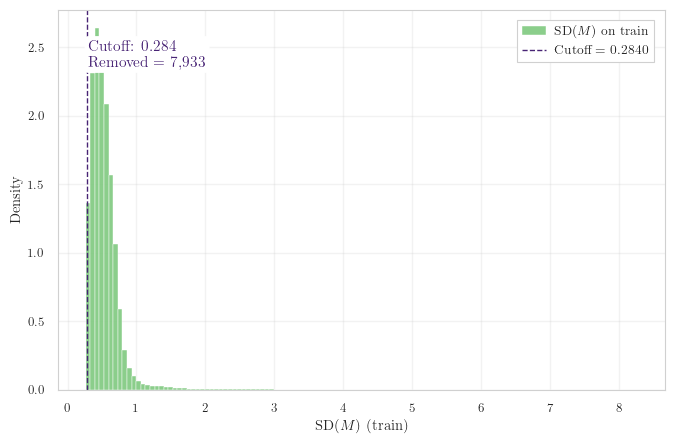

Kept = 380,778 / 388,711 CpGs (Removed = 7,933)


In [9]:
# =============================
# STEP 2 — PLOT: SD(M) distribution + 2% cutoff (train-only)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 2 — SD(M) distribution on TRAIN with variance cutoff (train-only): 2%\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

# Recompute pre-filter SD (identical to STEP 2 input)
M_train_pre = beta_to_m(B_train, eps=EPS_M).astype(np.float32)

sd_pre = M_train_pre.std(axis=0, ddof=1)
thr = float(np.quantile(sd_pre, VAR_DROP_FRAC))

total = int(sd_pre.size)
removed = int((~keep_mask).sum())
kept = total - removed

fig, ax = plt.subplots()

# Histogram (same green as Edgar)
HIST_COLOR = "#7FC97F"
ax.hist(
    sd_pre,
    bins=120,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label=r"$\mathrm{SD}(M)$ on train",
    zorder=1,
)

# Cutoff line
cut_color = plt.cm.viridis(0.10)
ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.0,
    color=cut_color,
    label=rf"Cutoff = {thr:.4f}",
    zorder=2,
)

ax.set_xlabel(r"$\mathrm{SD}(M)$ (train)")
ax.set_ylabel("Density")

# Annotation
X_SHIFT = 0.02
ymax = ax.get_ylim()[1]

ax.text(
    thr + X_SHIFT,
    ymax * 0.92,
    f"Cutoff: {thr:.3f}\nRemoved = {removed:,}",
    color=cut_color,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / "GSE225845_sdM_variance_filter.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

print(f"Kept = {kept:,} / {total:,} CpGs (Removed = {removed:,})")


In [10]:
# -----------------------------
# STEP 3 — Repeated Stratified K-Fold stability ranking (train-only, DIRECTIVE-COMPLIANT)
#   K=5, R=10
#   per split:
#     - compute MWU p-values on TRAIN-FOLD only
#     - compute |ΔM| and sign on TRAIN-FOLD only (for ranking)
#     - compute sign on VAL-FOLD (for stability check)
#   aggregate across splits:
#     score = 0.5*mean(rank_p_train) + 0.5*mean(rank_|ΔM|_train)
#     stability_sign = fraction of splits where sign_train == sign_val (and non-zero)
#     stability_sign >= 0.75
#     |ΔM| >= 0.15 (fallback 0.10 if too few candidates)
#   output: top 15k CpGs (candidates)
# -----------------------------

from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import mannwhitneyu

print("\n" + "=" * 90)
print("STEP 3 — RSKF stability ranking (K=5, R=10): score=0.5*rank_p + 0.5*rank_|ΔM|")
print("=" * 90)

# CONFIG
K_FOLDS = 5
R_REPEATS = 10
STABILITY_SIGN_MIN = 0.75
DELTA_M_THR_MAIN = 0.15
DELTA_M_THR_FALLBACK = 0.10
TOP_CANDIDATES = 15000
MIN_CANDIDATES_TARGET = 15000  # "collassa" if well below this

# Assumes available from STEP 2 (post-Edgar + optional var filter):
#   M_train (n_train, p), y_train (n_train,), cpg_cols_current (p,)
X = M_train
y = y_train
cols = np.array(cpg_cols_current, dtype=object)

n, p = X.shape
rkf = RepeatedStratifiedKFold(n_splits=K_FOLDS, n_repeats=R_REPEATS, random_state=RANDOM_STATE)
n_splits_total = K_FOLDS * R_REPEATS
print(f"Train: n={n} | p={p:,} | splits={n_splits_total} (K={K_FOLDS}, R={R_REPEATS})")

# accumulators for score
rank_p_sum = np.zeros(p, dtype=np.float64)
rank_dm_sum = np.zeros(p, dtype=np.float64)

# accumulators for sign stability (train vs val)
sign_agree_count = np.zeros(p, dtype=np.int32)   # count splits where sign_train == sign_val and both non-zero
sign_valid_count = np.zeros(p, dtype=np.int32)   # count splits where both classes present in train+val and signs non-zero

valid_splits_for_score = 0

def _ranks_ascending(values: np.ndarray) -> np.ndarray:
    """Return 1..p ranks, where smaller values -> smaller rank (best=1)."""
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

def _ranks_descending(values: np.ndarray) -> np.ndarray:
    """Return 1..p ranks, where larger values -> smaller rank (best=1)."""
    order = np.argsort(-values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

for split_id, (train_idx, val_idx) in enumerate(rkf.split(X, y), start=1):
    X_tr = X[train_idx]
    y_tr = y[train_idx]
    X_va = X[val_idx]
    y_va = y[val_idx]

    # ensure both classes present in both folds (should hold with stratification, but keep safe)
    tr0 = (y_tr == 0); tr1 = (y_tr == 1)
    va0 = (y_va == 0); va1 = (y_va == 1)
    if tr0.sum() == 0 or tr1.sum() == 0 or va0.sum() == 0 or va1.sum() == 0:
        continue

    X0_tr = X_tr[tr0]; X1_tr = X_tr[tr1]
    X0_va = X_va[va0]; X1_va = X_va[va1]

    # TRAIN-FOLD ΔM (signed + abs) used for ranking
    dM_tr = X1_tr.mean(axis=0) - X0_tr.mean(axis=0)
    abs_dM_tr = np.abs(dM_tr)

    # VAL-FOLD ΔM only for sign stability
    dM_va = X1_va.mean(axis=0) - X0_va.mean(axis=0)

    sign_tr = np.sign(dM_tr).astype(np.int8)  # -1,0,+1
    sign_va = np.sign(dM_va).astype(np.int8)

    # sign stability: count agreement where both non-zero
    nonzero = (sign_tr != 0) & (sign_va != 0)
    sign_valid_count += nonzero.astype(np.int32)
    sign_agree_count += (nonzero & (sign_tr == sign_va)).astype(np.int32)

    # MWU p-values on TRAIN-FOLD only
    # --- PREFILTER by |ΔM| to avoid MWU on all CpGs ---
    PREFILTER_TOP_DM = 50000   # you can tune (30k–70k reasonable)
    PRINT_EVERY = 1            # progress frequency
    
    # 1) prefilter indices by |ΔM| (train-fold)
    if PREFILTER_TOP_DM is not None and PREFILTER_TOP_DM < p:
        idx_pf = np.argpartition(-abs_dM_tr, PREFILTER_TOP_DM - 1)[:PREFILTER_TOP_DM]
    else:
        idx_pf = np.arange(p)
    
    # 2) MWU only on prefiltered CpGs
    pvals = np.ones(p, dtype=np.float64)  # default worst p-value
    for j in idx_pf:
        pvals[j] = mannwhitneyu(
            X0_tr[:, j], X1_tr[:, j],
            alternative="two-sided",
            method="asymptotic"
        ).pvalue


    # ranks per split (TRAIN-FOLD only)
    r_p = _ranks_ascending(pvals)       # best small p -> rank 1
    r_dm = _ranks_descending(abs_dM_tr) # best large |ΔM| -> rank 1

    rank_p_sum += r_p
    rank_dm_sum += r_dm
    valid_splits_for_score += 1

    if split_id % PRINT_EVERY == 0 or split_id == n_splits_total:
        print(f"  done split {split_id:>3}/{n_splits_total} | pf={idx_pf.size:,} | valid_for_score={valid_splits_for_score}")

if valid_splits_for_score == 0:
    raise RuntimeError("No valid splits computed in RSKF step (check labels / stratification).")

# aggregate score
mean_rank_p = rank_p_sum / valid_splits_for_score
mean_rank_dm = rank_dm_sum / valid_splits_for_score
score = 0.5 * mean_rank_p + 0.5 * mean_rank_dm

# stability_sign = fraction of splits where sign_train == sign_val (only where both non-zero)
stability_sign = np.zeros(p, dtype=np.float64)
nz = sign_valid_count > 0
stability_sign[nz] = sign_agree_count[nz] / sign_valid_count[nz]
# if never valid (rare), keep 0 stability (will be filtered out)

# global ΔM estimate on full TRAIN (used for thresholding)
dM_full = X[y == 1].mean(axis=0) - X[y == 0].mean(axis=0)
abs_dM_full = np.abs(dM_full)

# candidate filter with fallback
thr = DELTA_M_THR_MAIN
mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
n_cand = int(mask_cand.sum())
print(f"Candidates with |ΔM|>={thr:.2f} and stability_sign>={STABILITY_SIGN_MIN:.2f}: {n_cand:,}")

if n_cand < MIN_CANDIDATES_TARGET:
    thr = DELTA_M_THR_FALLBACK
    mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
    n_cand = int(mask_cand.sum())
    print(f"Fallback |ΔM|>={thr:.2f}: candidates={n_cand:,}")

if n_cand == 0:
    raise RuntimeError("Step 3 produced 0 candidates even after fallback. Lower thresholds or inspect data.")

# pick top 15k by score (lower is better)
cand_idx = np.where(mask_cand)[0]
order = np.argsort(score[cand_idx], kind="mergesort")
cand_idx_sorted = cand_idx[order]
cand_idx_top = cand_idx_sorted[:min(TOP_CANDIDATES, cand_idx_sorted.size)]

cpg_candidates = cols[cand_idx_top]

# keep useful stats for later steps (region anchoring / reporting)
step3_stats = {
    "score": score[cand_idx_top],
    "mean_rank_p": mean_rank_p[cand_idx_top],
    "mean_rank_abs_dM": mean_rank_dm[cand_idx_top],
    "stability_sign": stability_sign[cand_idx_top],
    "deltaM_full": dM_full[cand_idx_top],
    "abs_deltaM_full": abs_dM_full[cand_idx_top],
    "used_deltaM_thr": thr,
    "valid_splits_for_score": valid_splits_for_score,
    "sign_valid_splits": sign_valid_count[cand_idx_top],
}

print(f"Selected top candidates: {len(cpg_candidates):,} (target {TOP_CANDIDATES:,})")
print("Example:", cpg_candidates[:5].tolist())



STEP 3 — RSKF stability ranking (K=5, R=10): score=0.5*rank_p + 0.5*rank_|ΔM|
Train: n=202 | p=388,711 | splits=50 (K=5, R=10)
  done split   1/50 | pf=50,000 | valid_for_score=1
  done split   2/50 | pf=50,000 | valid_for_score=2
  done split   3/50 | pf=50,000 | valid_for_score=3
  done split   4/50 | pf=50,000 | valid_for_score=4
  done split   5/50 | pf=50,000 | valid_for_score=5
  done split   6/50 | pf=50,000 | valid_for_score=6
  done split   7/50 | pf=50,000 | valid_for_score=7
  done split   8/50 | pf=50,000 | valid_for_score=8
  done split   9/50 | pf=50,000 | valid_for_score=9
  done split  10/50 | pf=50,000 | valid_for_score=10
  done split  11/50 | pf=50,000 | valid_for_score=11
  done split  12/50 | pf=50,000 | valid_for_score=12
  done split  13/50 | pf=50,000 | valid_for_score=13
  done split  14/50 | pf=50,000 | valid_for_score=14
  done split  15/50 | pf=50,000 | valid_for_score=15
  done split  16/50 | pf=50,000 | valid_for_score=16
  done split  17/50 | pf=50,000 |


STEP 3 — stability_sign distribution (train↔val agreement)

Saved plot to: plots_outputs/GSE225845_stability_sign_distribution.pdf


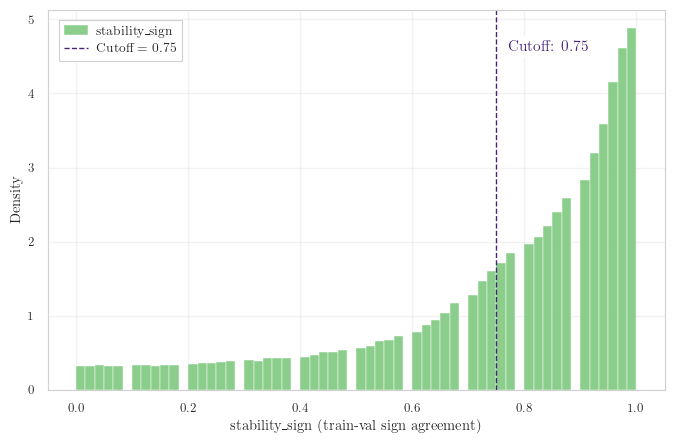

In [11]:
# =============================
# STEP 3 — PLOT: stability_sign distribution (train↔val agreement)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_NAME = "GSE225845"   # <-- modifica se necessario

print("\nSTEP 3 — stability_sign distribution (train↔val agreement)\n")

apply_thesis_style(use_tex=True, legend_position="upper left", legend_outside=False)

fig, ax = plt.subplots()

HIST_COLOR = "#7FC97F"
CUT_COLOR = plt.cm.viridis(0.10)

ax.hist(
    stability_sign,
    bins=60,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label="stability_sign",
    zorder=1,
)

ax.axvline(
    STABILITY_SIGN_MIN,
    linestyle="--",
    linewidth=1.0,
    color=CUT_COLOR,
    label=rf"Cutoff = {STABILITY_SIGN_MIN:.2f}",
    zorder=2,
)

ax.set_xlabel("stability_sign (train-val sign agreement)")
ax.set_ylabel("Density")

# annotation (white background only, no border)
ymax = ax.get_ylim()[1]
ax.text(
    STABILITY_SIGN_MIN + 0.02,
    ymax * 0.92,
    f"Cutoff: {STABILITY_SIGN_MIN:.2f}",
    color=CUT_COLOR,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / f"{DATASET_NAME}_stability_sign_distribution.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {pdf_path}")

plt.show()



STEP 3 — RSKF score vs |ΔM| on TRAIN (candidates highlighted)

Saved plot to: plots_outputs/GSE225845_absDeltaM_vs_score.pdf


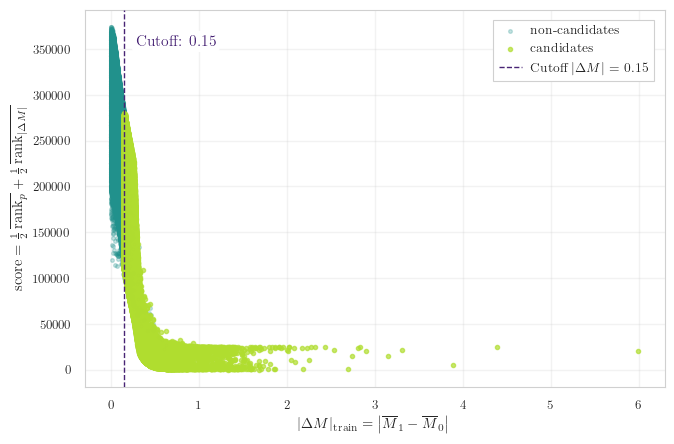

In [20]:
# =============================
# STEP 3 — PLOT: RSKF score vs |ΔM| (viridis coherent palette)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 3 — RSKF score vs |ΔM| on TRAIN (candidates highlighted)\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

score = np.asarray(score, dtype=float)
abs_dM_full = np.asarray(abs_dM_full, dtype=float)
mask_cand = np.asarray(mask_cand, dtype=bool)

idx_cand = np.where(mask_cand)[0]
idx_non = np.where(~mask_cand)[0]

MAX_NON = 25000
if idx_non.size > MAX_NON:
    rng = np.random.default_rng(RANDOM_STATE)
    idx_non = rng.choice(idx_non, size=MAX_NON, replace=False)

# --- VIRIDIS PALETTE ---
c_non   = plt.cm.viridis(0.50)  # verde medio/scuro (tolte)
c_cand  = plt.cm.viridis(0.88)  # giallo-verde chiaro (tenute)
c_line  = plt.cm.viridis(0.10)  # verde scuro (cutoff)

fig, ax = plt.subplots()

ax.scatter(
    abs_dM_full[idx_non],
    score[idx_non],
    s=7,
    alpha=0.25,
    color=c_non,
    label="non-candidates",
    zorder=1,
)

ax.scatter(
    abs_dM_full[idx_cand],
    score[idx_cand],
    s=9,
    alpha=0.70,
    color=c_cand,
    label="candidates",
    zorder=2,
)

ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.0,
    color=c_line,
    label=rf"Cutoff $|\Delta M|$ = {thr:.2f}",
    zorder=3,
)

ax.set_xlabel(r"$|\Delta M|_{\mathrm{train}} = \left|\overline{M}_{1} - \overline{M}_{0}\right|$")
ax.set_ylabel(
    r"$\mathrm{score} = \frac{1}{2}\,\overline{\mathrm{rank}_{p}} + \frac{1}{2}\,\overline{\mathrm{rank}_{|\Delta M|}}$"
)

# Annotazione cutoff stile Edgar
ymax = ax.get_ylim()[1]
x_text = thr + 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])

ax.text(
    x_text,
    ymax * 0.93,
    f"Cutoff: {thr:.2f}",
    color=c_line,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUTDIR / f"{DATASET_NAME}_absDeltaM_vs_score.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()


In [21]:
# =============================
# STEP 3 — CHECK: Spearman corr(score, |ΔM|) on TRAIN
#   tells you if the score is basically dominated by effect size
# =============================

import numpy as np
from scipy.stats import spearmanr

print("\nSTEP 3 — Spearman correlation between score and |ΔM| (full train)\n")

# Assumes from STEP 3 you have:
#   score        : np.ndarray (len p)
#   abs_dM_full  : np.ndarray (len p)
#   mask_cand    : np.ndarray bool (len p)  [optional]
#   cpg_cols_current : list/array CpG ids (len p) [optional]

score_arr = np.asarray(score, dtype=float)
absdm_arr = np.asarray(abs_dM_full, dtype=float)

# Safety: remove NaNs/Infs if any
ok = np.isfinite(score_arr) & np.isfinite(absdm_arr)
score_ok = score_arr[ok]
absdm_ok = absdm_arr[ok]

# Spearman on all CpGs
rho_all, p_all = spearmanr(score_ok, absdm_ok)

print(f"[ALL CpGs] Spearman rho(score, |ΔM|) = {rho_all:.4f} | p-value = {p_all:.3e} | n = {score_ok.size:,}")

# Optional: Spearman on candidates only (after stability + |ΔM| thresholds)
if "mask_cand" in globals():
    mask = np.asarray(mask_cand, dtype=bool)
    mask = mask & ok
    if mask.sum() > 10:
        rho_c, p_c = spearmanr(score_arr[mask], absdm_arr[mask])
        print(f"[CANDIDATES] Spearman rho(score, |ΔM|) = {rho_c:.4f} | p-value = {p_c:.3e} | n = {int(mask.sum()):,}")
    else:
        print("[CANDIDATES] not enough points to compute reliably.")

# Optional: quick diagnostic interpretation
if np.isfinite(rho_all):
    if abs(rho_all) > 0.90:
        print("Interpretation: |rho|>0.90 ⇒ score is (almost) monotone in |ΔM| → ranking dominated by effect size.")
    elif abs(rho_all) > 0.70:
        print("Interpretation: 0.70<|rho|<=0.90 ⇒ strong link: effect size is a major driver, MWU still contributes.")
    else:
        print("Interpretation: |rho|<=0.70 ⇒ MWU ranks contribute materially beyond effect size.")



STEP 3 — Spearman correlation between score and |ΔM| (full train)

[ALL CpGs] Spearman rho(score, |ΔM|) = -0.7970 | p-value = 0.000e+00 | n = 388,711
[CANDIDATES] Spearman rho(score, |ΔM|) = -0.8022 | p-value = 0.000e+00 | n = 162,655
Interpretation: 0.70<|rho|<=0.90 ⇒ strong link: effect size is a major driver, MWU still contributes.


In [19]:
print("working")

working


In [24]:
from pathlib import Path
import polars as pl

# CONFIG
DATASET = "GSE225845"   # cambia: GSE287331 / GSE69914
OUTDIR = Path("./region_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# (opzionale ma consigliato) ordina e forza schema stabile
region_summary_out = (
    region_summary
    .select([
        "island_id",
        "n_cpgs",
        "fraction_stable",
        "median_score",
        "region_score",
        "picked_m",
    ])
    .with_columns([
        pl.col("island_id").cast(pl.Utf8),
        pl.col("n_cpgs").cast(pl.Int64),
        pl.col("picked_m").cast(pl.Int64),
        pl.col("fraction_stable").cast(pl.Float64),
        pl.col("median_score").cast(pl.Float64),
        pl.col("region_score").cast(pl.Float64),
    ])
    .sort(["region_score", "island_id"])
)

csv_path = OUTDIR / f"{DATASET}_region_summary.csv"
parq_path = OUTDIR / f"{DATASET}_region_summary.parquet"

region_summary_out.write_csv(csv_path)
region_summary_out.write_parquet(parq_path)

print(f"Saved CSV:   {csv_path}")
print(f"Saved PARQ:  {parq_path}")
print(f"Rows: {region_summary_out.height:,}")


Saved CSV:   region_outputs/GSE225845_region_summary.csv
Saved PARQ:  region_outputs/GSE225845_region_summary.parquet
Rows: 498


In [17]:
# -----------------------------
# STEP 3b — Region anchoring su CpG islands (DIRECTIVE-COMPLIANT)
#   region_score = median(score) × fraction_stable
#   fraction_stable >= 0.6, >= 2 CpG per regione
#   top-m (m=2-3) per regione -> Pool A [anchored]
#   resto -> Pool B [non-anchored]
#
# NOTE (aderenza):
# - "fraction_stable" qui è calcolata su CpG che rispettano i vincoli di STEP 3:
#     stability_sign >= 0.75  AND  |ΔM| >= thr_usato_in_step3
#   (thr_usato_in_step3 = 0.15 oppure 0.10 se fallback)
# -----------------------------

import numpy as np
import polars as pl

print("\n" + "=" * 90)
print("STEP 3b — Region anchoring su CpG islands")
print("=" * 90)

# CONFIG
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"
MANIFEST_CPG_COL = "IlmnID"
MANIFEST_ISLAND_NAME_COL = "UCSC_CpG_Islands_Name"
MANIFEST_REL_COL = "Relation_to_UCSC_CpG_Island"

ANCHOR_CONTEXT = {"Island"}        # anchoring strictly on islands
FRACTION_STABLE_MIN = 0.60
MIN_CPGS_PER_REGION = 2
TOP_M_PER_REGION = 3               # set 2 or 3

# Assumes from STEP 3:
#   cpg_candidates : (n_cand,)
#   step3_stats["score"] : (n_cand,)   lower is better
#   step3_stats["stability_sign"] : (n_cand,)
#   step3_stats["abs_deltaM_full"] : (n_cand,)
#   step3_stats["used_deltaM_thr"] : scalar (0.15 or 0.10)
cand = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)
cand_stab  = np.array(step3_stats["stability_sign"], dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
thr_used   = float(step3_stats["used_deltaM_thr"])

if not (cand.shape[0] == cand_score.shape[0] == cand_stab.shape[0] == cand_absdM.shape[0]):
    raise RuntimeError("STEP 3b: candidate arrays are misaligned (cpg_candidates vs step3_stats).")

# Define CpG-level "stable" flag per STEP 3 directive (within the candidate set)
stable_cpg_flag = (cand_stab >= STABILITY_SIGN_MIN) & (cand_absdM >= thr_used)

print(f"Candidates: {cand.size:,}")
print(f"ΔM threshold used in STEP 3: {thr_used:.2f}")
print(f"Stable CpGs inside candidates (stab>=0.75 AND |ΔM|>=thr): {int(stable_cpg_flag.sum()):,}")

# -----------------------------
# A) Build CpG -> island mapping (only Island context and named islands)
# -----------------------------
def load_manifest_with_real_header(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        start_row = None
        for i, line in enumerate(f):
            if line.startswith("IlmnID"):
                start_row = i
                break
    if start_row is None:
        raise ValueError(f"Non trovo header 'IlmnID' in: {path}")
    return pd.read_csv(path, skiprows=start_row, low_memory=False)

mf = load_manifest_with_real_header(MANIFEST_PATH)

# Keep only required columns
mf = mf[[MANIFEST_CPG_COL, MANIFEST_ISLAND_NAME_COL, MANIFEST_REL_COL]].copy()

mf.columns = ["cpg", "island", "rel"]

mf["cpg"] = mf["cpg"].astype(str)
mf["island"] = mf["island"].fillna("").astype(str).str.strip()
mf["rel"] = mf["rel"].fillna("").astype(str).str.strip()

# Filter strictly Island context + named islands
mf_island = mf[
    (mf["rel"].isin(list(ANCHOR_CONTEXT))) &
    (mf["island"] != "")
]

# CpG -> island dictionary
cpg_to_island = dict(zip(mf_island["cpg"], mf_island["island"]))

# map candidates to islands
island_id = np.array([cpg_to_island.get(c, None) for c in cand], dtype=object)
in_island = island_id != None
print(f"Mapped to named CpG islands (context={ANCHOR_CONTEXT}): {int(in_island.sum()):,}")

# -----------------------------
# B) Group by island, compute region_score and pick top-m CpGs per selected region
# -----------------------------
island_to_idx = {}
for i, rid in enumerate(island_id):
    if rid is None:
        continue
    island_to_idx.setdefault(rid, []).append(i)

region_rows = []
poolA_idx = []

for rid, idxs in island_to_idx.items():
    idxs = np.array(idxs, dtype=int)

    # constraint: >= 2 CpGs per region
    if idxs.size < MIN_CPGS_PER_REGION:
        continue

    # fraction_stable computed on STEP3 "stable" definition
    frac_stable = float(stable_cpg_flag[idxs].mean())
    if frac_stable < FRACTION_STABLE_MIN:
        continue

    # region_score = median(score) * fraction_stable
    med_score = float(np.median(cand_score[idxs]))
    region_score = med_score * frac_stable

    # top-m per region by candidate score (lower better)
    order = np.argsort(cand_score[idxs], kind="mergesort")
    chosen = idxs[order[:min(TOP_M_PER_REGION, idxs.size)]]
    poolA_idx.extend(chosen.tolist())

    region_rows.append((rid, idxs.size, frac_stable, med_score, region_score, chosen.size))

poolA_idx = np.array(sorted(set(poolA_idx)), dtype=int)

# -----------------------------
# C) Final pools
# -----------------------------
poolA_cpgs = cand[poolA_idx]  # anchored

maskA = np.zeros(cand.size, dtype=bool)
maskA[poolA_idx] = True
poolB_cpgs = cand[~maskA]     # non-anchored

print(f"Selected regions (pass constraints): {len(region_rows):,}")
print(f"Pool A (anchored) CpGs: {poolA_cpgs.size:,}  (top-m={TOP_M_PER_REGION} per region)")
print(f"Pool B (non-anchored) CpGs: {poolB_cpgs.size:,}")

region_summary = (
    pl.DataFrame(
        region_rows,
        schema=["island_id", "n_cpgs", "fraction_stable", "median_score", "region_score", "picked_m"]
    ).sort("region_score")
)

print("Top 5 regions by region_score (lower is better):")
print(region_summary.head(5))

# Outputs:
#   poolA_cpgs, poolB_cpgs, region_summary



STEP 3b — Region anchoring su CpG islands
Candidates: 15,000
ΔM threshold used in STEP 3: 0.15
Stable CpGs inside candidates (stab>=0.75 AND |ΔM|>=thr): 15,000
Mapped to named CpG islands (context={'Island'}): 3,314
Selected regions (pass constraints): 498
Pool A (anchored) CpGs: 1,157  (top-m=3 per region)
Pool B (non-anchored) CpGs: 13,843
Top 5 regions by region_score (lower is better):
shape: (5, 6)
┌──────────────────────────┬────────┬─────────────────┬──────────────┬──────────────┬──────────┐
│ island_id                ┆ n_cpgs ┆ fraction_stable ┆ median_score ┆ region_score ┆ picked_m │
│ ---                      ┆ ---    ┆ ---             ┆ ---          ┆ ---          ┆ ---      │
│ str                      ┆ i64    ┆ f64             ┆ f64          ┆ f64          ┆ i64      │
╞══════════════════════════╪════════╪═════════════════╪══════════════╪══════════════╪══════════╡
│ chr20:62679424-62680883  ┆ 3      ┆ 1.0             ┆ 738.84       ┆ 738.84       ┆ 3        │
│ chr3:179


STEP 3b — Region anchoring: selected regions = 498

Saved plot to: plots_outputs/GSE225845_region_score_distribution.pdf


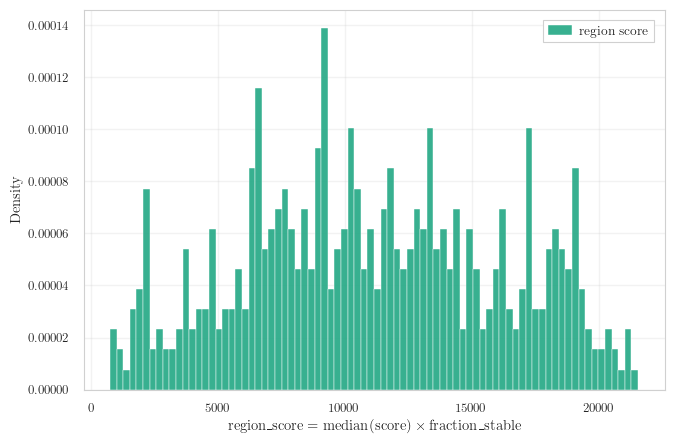

In [22]:
# =============================
# STEP 3b — PLOT: Region_score distribution (selected regions)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


print(f"\nSTEP 3b — Region anchoring: selected regions = {len(region_summary):,}\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

# extract region_score
rs = region_summary.select("region_score").to_numpy().ravel().astype(float)

fig, ax = plt.subplots()

# histogram (viridis mid-green)
hist_color = plt.cm.viridis(0.60)

ax.hist(
    rs,
    bins=80,
    density=True,
    alpha=0.90,
    color=hist_color,
    edgecolor="white",
    linewidth=0.35,
    label=r"$\mathrm{region \; score}$",
)

ax.set_xlabel(r"$\mathrm{region\_score} = \mathrm{median}(\mathrm{score}) \times \mathrm{fraction\_stable}$")
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / f"{DATASET_NAME}_region_score_distribution.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {pdf_path}")

plt.show()


In [26]:
# -----------------------------
# STEP 4 — Correlation clustering separato (DIRECTIVE-COMPLIANT)
#   Pool A: |r| >= 0.85  -> connected components -> 1 CpG/cluster (best STEP3 score)
#   Pool B: |r| >= 0.85  -> connected components -> 1 CpG/cluster (best STEP3 score)
#   Output: unione dei rappresentanti (A prima di B, unique)
#
# NOTE (aderenza):
# - correlazioni calcolate SOLO su TRAIN (M_train)
# - "miglior score" = minimo STEP3 score (0.5·mean(rank_p)+0.5·mean(rank_|ΔM|))
# - cluster = componenti connesse del grafo soglia |r|>=thr
# -----------------------------

import numpy as np

print("\n" + "=" * 90)
print("STEP 4 — Correlation clustering separato (Pool A, Pool B) |r|>=0.85")
print("=" * 90)

# CONFIG
CORR_CLUSTER_THR = 0.85

# Assumes from previous steps:
#   - M_train : (n_train, p_all)  TRAIN matrix in M-space (post STEP 2)
#   - cpg_cols_current : (p_all,) CpG names aligned to columns of M_train
#   - cpg_candidates : (n_cand,) top candidates from STEP 3
#   - step3_stats["score"] aligned to cpg_candidates (lower is better)
#   - poolA_cpgs, poolB_cpgs from STEP 3b

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all)}

cand = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)

# Map CpG -> STEP3 score (used to pick representative)
score_map = {c: s for c, s in zip(cand, cand_score)}

def _build_Z(pool_cpgs: np.ndarray):
    """
    Return standardized TRAIN matrix Z for pool CpGs and the ordered CpG list (aligned to Z columns).
    Standardization is per-CpG on TRAIN only.
    """
    pool = np.array([c for c in pool_cpgs if c in col_to_j], dtype=object)
    if pool.size == 0:
        return np.empty((M_train.shape[0], 0), dtype=np.float32), pool

    jj = np.array([col_to_j[c] for c in pool], dtype=int)
    Xp = M_train[:, jj].astype(np.float32, copy=False)

    mu = Xp.mean(axis=0)
    sd = Xp.std(axis=0, ddof=1) + 1e-12
    Z = (Xp - mu) / sd
    return Z, pool

def _connected_components_from_corr(Z: np.ndarray, thr: float):
    """
    Graph on CpGs where edge(i,j)=1 if |corr(i,j)|>=thr.
    Connected components = clusters.
    corr computed on standardized TRAIN data: C = (Z^T Z)/(n-1).
    """
    p = Z.shape[1]
    if p == 0:
        return []
    if p == 1:
        return [[0]]

    n = Z.shape[0]
    C = (Z.T @ Z) / (n - 1)
    A = (np.abs(C) >= thr)
    np.fill_diagonal(A, True)

    visited = np.zeros(p, dtype=bool)
    comps = []
    for i in range(p):
        if visited[i]:
            continue
        stack = [i]
        visited[i] = True
        comp = []
        while stack:
            u = stack.pop()
            comp.append(u)
            nbrs = np.where(A[u])[0]
            for v in nbrs:
                if not visited[v]:
                    visited[v] = True
                    stack.append(v)
        comps.append(comp)
    return comps

def _pick_rep_by_best_score(pool_order: np.ndarray, comps):
    """Pick 1 CpG per component by minimal STEP3 score (lower is better)."""
    reps = []
    for comp in comps:
        members = pool_order[np.array(comp, dtype=int)]
        scores = np.array([score_map.get(c, np.inf) for c in members], dtype=float)
        best = members[int(np.argmin(scores))]
        reps.append(best)
    return np.array(reps, dtype=object)

def cluster_pool(pool_name: str, pool_cpgs: np.ndarray, thr: float):
    Z, pool_order = _build_Z(pool_cpgs)
    print(f"{pool_name}: CpGs in pool={pool_order.size:,}")

    if pool_order.size == 0:
        return np.array([], dtype=object), np.array([], dtype=int)

    comps = _connected_components_from_corr(Z, thr=thr)
    reps = _pick_rep_by_best_score(pool_order, comps)

    sizes = np.array([len(c) for c in comps], dtype=int)
    print(f"{pool_name}: clusters={len(comps):,} | reps={reps.size:,} | "
          f"median_cluster_size={int(np.median(sizes))} | max_cluster_size={int(sizes.max())}")
    return reps, sizes

# Separate clustering as per directive
reps_A, sizes_A = cluster_pool("Pool A (anchored)", poolA_cpgs, thr=CORR_CLUSTER_THR)
reps_B, sizes_B = cluster_pool("Pool B (non-anchored)", poolB_cpgs, thr=CORR_CLUSTER_THR)

# Union of representatives (A first, then B), unique
reps_union = np.array(list(dict.fromkeys(np.concatenate([reps_A, reps_B]).tolist())), dtype=object)

print(f"Union representatives: {reps_union.size:,} (A={reps_A.size:,}, B={reps_B.size:,})")

# Outputs for STEP 5:
#   reps_A, reps_B, reps_union



STEP 4 — Correlation clustering separato (Pool A, Pool B) |r|>=0.85
Pool A (anchored): CpGs in pool=1,157
Pool A (anchored): clusters=958 | reps=958 | median_cluster_size=1 | max_cluster_size=66
Pool B (non-anchored): CpGs in pool=13,843
Pool B (non-anchored): clusters=5,495 | reps=5,495 | median_cluster_size=1 | max_cluster_size=7046
Union representatives: 6,453 (A=958, B=5,495)


[OK] Saved PDF → figures/step4/GSE225845_cluster_size_ccdf_loglog_r0.85.pdf


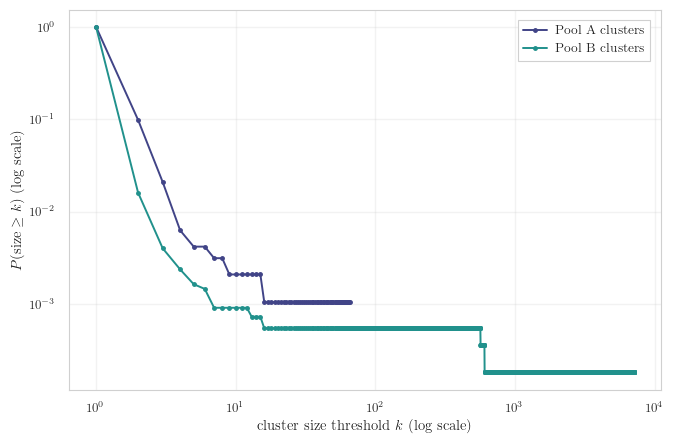

Correlation clustering tail (CCDF), $|r|\geq 0.85$


In [30]:
# =============================
# STEP 4 — PLOT (CCDF log-log, Viridis): Cluster size tail (Pool A vs Pool B)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

def ccdf_from_sizes(sizes: np.ndarray):
    sizes = np.asarray(sizes, dtype=int)
    sizes = sizes[sizes >= 1]
    if sizes.size == 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    max_k = int(sizes.max())
    ks = np.arange(1, max_k + 1, dtype=int)

    hist = np.bincount(sizes, minlength=max_k + 1)
    tail_counts = np.cumsum(hist[::-1])[::-1]
    ccdf = tail_counts[ks] / float(sizes.size)
    return ks, ccdf

kA, ccdfA = ccdf_from_sizes(sizes_A)
kB, ccdfB = ccdf_from_sizes(sizes_B)

if ccdfA.size == 0 and ccdfB.size == 0:
    raise ValueError("Both sizes_A and sizes_B are empty.")

# --- Viridis colors ---
cmap = plt.cm.viridis
color_A = cmap(0.2)
color_B = cmap(0.5)

fig, ax = plt.subplots()

if ccdfA.size:
    ax.plot(kA, ccdfA,
            marker="o", markersize=2.5, linewidth=1.4,
            color=color_A, label="Pool A clusters")

if ccdfB.size:
    ax.plot(kB, ccdfB,
            marker="o", markersize=2.5, linewidth=1.4,
            color=color_B, label="Pool B clusters")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("cluster size threshold $k$ (log scale)")
ax.set_ylabel(r"$P(\mathrm{size}\geq k)$ (log scale)")


place_legend(ax)
fig.tight_layout()

OUT_DIR = Path("figures/step4")
OUT_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUT_DIR / f"GSE225845_cluster_size_ccdf_loglog_r{CORR_CLUSTER_THR:.2f}.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"[OK] Saved PDF → {pdf_path}")

plt.show()
print(f"Correlation clustering tail (CCDF), $|r|\geq {CORR_CLUSTER_THR:.2f}$")

In [32]:
# -----------------------------
# STEP 5 — Diversificazione soft + greedy (DIRECTIVE-COMPLIANT)
#   Vincoli (soft, target):
#     - chr <= 20% (sul K target, non dinamico su n_next)
#     - contesto <= 65% (sul K target, non dinamico su n_next)
#     - max 15 CpG / 500kb (vincolo spaziale hard finché non si rilassa)
#   Allentamento: spaziale -> contesto -> chr
# -----------------------------

import numpy as np
import polars as pl

print("\n" + "=" * 90)
print("STEP 5 — Diversification greedy with soft constraints + relaxation (spatial→context→chr)")
print("=" * 90)

# CONFIG
K_TARGET = 5000
CHR_MAX_FRAC = 0.20
CTX_MAX_FRAC = 0.65
WIN_BP = 500_000
MAX_PER_WIN = 15

MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"
MANIFEST_CPG_COL = "IlmnID"
MANIFEST_CHR_COL = "CHR"
MANIFEST_POS_COL = "MAPINFO"
MANIFEST_CTX_COL = "Relation_to_UCSC_CpG_Island"

# Assumes:
#   reps_union : (n_reps,)
#   score_map  : dict CpG -> STEP3 score (lower is better)
reps = np.array(reps_union, dtype=object)
if reps.size == 0:
    raise RuntimeError("STEP 5: reps_union is empty.")

# -----------------------------
# A) Manifest mapping CpG -> chr, pos, context
# -----------------------------
# -----------------------------
# Manifest load (robust) + mapping reps
# -----------------------------
mf_pd = load_manifest_with_real_header(MANIFEST_PATH)

# Convert to Polars and normalize the needed columns
mf = pl.from_pandas(mf_pd).select([
    pl.col(MANIFEST_CPG_COL).cast(pl.Utf8).alias("cpg"),
    pl.col(MANIFEST_CHR_COL).cast(pl.Utf8).alias("chr"),
    pl.col(MANIFEST_POS_COL).cast(pl.Int64).alias("pos"),
    pl.col(MANIFEST_CTX_COL).cast(pl.Utf8).alias("ctx"),
]).with_columns([
    pl.col("cpg").fill_null("").str.strip_chars(),
    pl.col("chr").fill_null("").str.strip_chars(),
    pl.col("ctx").fill_null("OpenSea").str.strip_chars(),
])

# Filter only reps
mf = mf.filter(pl.col("cpg").is_in(reps.tolist()))

# Build maps
cpg_to_chr = dict(zip(mf["cpg"].to_list(), mf["chr"].to_list()))
cpg_to_pos = dict(zip(mf["cpg"].to_list(), mf["pos"].to_list()))
cpg_to_ctx = dict(zip(mf["cpg"].to_list(), mf["ctx"].to_list()))

# Keep only reps that map to chr+pos
mapped = []
for c in reps:
    ch = cpg_to_chr.get(c, "")
    ps = cpg_to_pos.get(c, None)
    if ch == "" or ps is None:
        continue
    mapped.append(c)

mapped = np.array(mapped, dtype=object)  # se ti serve come array

print(f"Reps union: {reps.size:,}")
print(f"Mapped reps (chr+pos available): {mapped.size:,}")
if mapped.size == 0:
    raise RuntimeError("STEP 5: No CpGs have manifest chr/pos mapping.")

# -----------------------------
# B) Greedy order by STEP3 score (lower better)
# -----------------------------
scores = np.array([score_map.get(c, np.inf) for c in mapped], dtype=float)
order = np.argsort(scores, kind="mergesort")
cand = mapped[order]
cand_scores = scores[order]

# -----------------------------
# C) Diversification greedy with staged relaxation (budgets on K_TARGET)
# -----------------------------
def diversify_greedy_budgets(
    cand_cpgs: np.ndarray,
    cand_scores: np.ndarray,
    k_target: int,
    enforce_spatial: bool,
    enforce_context: bool,
    enforce_chr: bool,
):
    selected = []
    chr_counts = {}
    ctx_counts = {}
    win_counts = {}  # (chr, win_id) -> count

    # budgets computed vs final K target (directive intent)
    chr_budget = int(np.floor(CHR_MAX_FRAC * k_target))
    ctx_budget = int(np.floor(CTX_MAX_FRAC * k_target))
    chr_budget = max(chr_budget, 1)
    ctx_budget = max(ctx_budget, 1)

    def _ok_chr(ch):
        if not enforce_chr:
            return True
        return (chr_counts.get(ch, 0) + 1) <= chr_budget

    def _ok_ctx(ctx):
        if not enforce_context:
            return True
        return (ctx_counts.get(ctx, 0) + 1) <= ctx_budget

    def _ok_spatial(ch, pos):
        if not enforce_spatial:
            return True
        win_id = int(pos // WIN_BP)
        return (win_counts.get((ch, win_id), 0) + 1) <= MAX_PER_WIN

    for c, s in zip(cand_cpgs, cand_scores):
        if len(selected) >= k_target:
            break

        ch = cpg_to_chr.get(c, "")
        pos = cpg_to_pos.get(c, None)
        ctx = cpg_to_ctx.get(c, "OpenSea")
        if ch == "" or pos is None:
            continue

        if not _ok_spatial(ch, pos):
            continue
        if not _ok_ctx(ctx):
            continue
        if not _ok_chr(ch):
            continue

        # accept
        selected.append(c)
        chr_counts[ch] = chr_counts.get(ch, 0) + 1
        ctx_counts[ctx] = ctx_counts.get(ctx, 0) + 1
        win_id = int(pos // WIN_BP)
        win_counts[(ch, win_id)] = win_counts.get((ch, win_id), 0) + 1

    return np.array(selected, dtype=object), chr_counts, ctx_counts, win_counts, chr_budget, ctx_budget

stages = [
    ("strict",        True,  True,  True),
    ("relax_spatial", False, True,  True),
    ("relax_context", False, False, True),
    ("relax_chr",     False, False, False),
]

selected_final = None
stage_used = None
diag = None

k_eff = min(K_TARGET, cand.size)

for name, e_sp, e_ctx, e_chr in stages:
    sel, chr_ct, ctx_ct, win_ct, chr_budget, ctx_budget = diversify_greedy_budgets(
        cand, cand_scores,
        k_target=k_eff,
        enforce_spatial=e_sp,
        enforce_context=e_ctx,
        enforce_chr=e_chr,
    )
    print(f"Stage={name:>13} | selected={sel.size:,} / {k_eff:,} | chr_budget={chr_budget} | ctx_budget={ctx_budget}")
    selected_final = sel
    stage_used = name
    diag = (chr_ct, ctx_ct, win_ct)
    if sel.size >= k_eff:
        break

selected_diverse = selected_final
print(f"Final selected after diversification: {selected_diverse.size:,} | stage_used={stage_used}")

chr_ct, ctx_ct, win_ct = diag
top_chr = sorted(chr_ct.items(), key=lambda x: -x[1])[:5]
top_ctx = sorted(ctx_ct.items(), key=lambda x: -x[1])[:5]
print("Top 5 chr counts:", top_chr)
print("Top 5 ctx counts:", top_ctx)

# Output for STEP 6:
#   selected_diverse



STEP 5 — Diversification greedy with soft constraints + relaxation (spatial→context→chr)
Reps union: 6,453
Mapped reps (chr+pos available): 6,453
Stage=       strict | selected=5,000 / 5,000 | chr_budget=1000 | ctx_budget=3250
Final selected after diversification: 5,000 | stage_used=strict
Top 5 chr counts: [('1', 516), ('2', 377), ('19', 331), ('3', 288), ('7', 279)]
Top 5 ctx counts: [('Island', 2118), ('OpenSea', 1748), ('N_Shore', 533), ('S_Shore', 435), ('N_Shelf', 88)]


In [ ]:
# =============================
# STEP 5 — PLOT: Chromosome share in final diversified set
# =============================

import numpy as np
import matplotlib.pyplot as plt

# Assumes from STEP 5:
#   selected_diverse : np.ndarray of CpGs
#   cpg_to_chr : dict CpG -> chr
#   K_TARGET, CHR_MAX_FRAC

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

sel = np.array(selected_diverse, dtype=object)
chrs = np.array([cpg_to_chr.get(c, "") for c in sel], dtype=object)
chrs = chrs[chrs != ""]

# counts and fractions
uniq, cnt = np.unique(chrs, return_counts=True)
frac = cnt / cnt.sum()

# sort descending
ordr = np.argsort(-frac)
uniq, cnt, frac = uniq[ordr], cnt[ordr], frac[ordr]

fig, ax = plt.subplots()
ax.bar(np.arange(len(uniq)), frac)

ax.axhline(CHR_MAX_FRAC, linestyle="--", linewidth=1.2, label=rf"target max share = {CHR_MAX_FRAC:.2f}")

ax.set_xticks(np.arange(len(uniq)))
ax.set_xticklabels(uniq, rotation=90)
ax.set_ylabel("Fraction of selected CpGs")
ax.set_xlabel("Chromosome")
ax.set_title(f"Diversification result: chromosome composition (n={len(sel):,})")

place_legend(ax)
fig.tight_layout()
plt.show()


In [ ]:
# =============================
# STEP 5 — PLOT: Spatial density constraint check (max per 500kb window)
# =============================

import numpy as np
import matplotlib.pyplot as plt

# Assumes from STEP 5:
#   selected_diverse : np.ndarray of CpGs
#   cpg_to_chr, cpg_to_pos : dicts
#   WIN_BP, MAX_PER_WIN

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

sel = np.array(selected_diverse, dtype=object)
pairs = []
for c in sel:
    ch = cpg_to_chr.get(c, "")
    ps = cpg_to_pos.get(c, None)
    if ch == "" or ps is None:
        continue
    win = int(ps // WIN_BP)
    pairs.append((ch, win))

pairs = np.array(pairs, dtype=object)
if pairs.size == 0:
    raise RuntimeError("No mapped CpGs for spatial window check.")

# count per (chr,win)
keys, cnt = np.unique(pairs, return_counts=True, axis=0)

fig, ax = plt.subplots()
ax.hist(cnt, bins=np.arange(1, cnt.max() + 2) - 0.5, density=True, alpha=0.90, label="CpGs per 500kb window")

ax.axvline(MAX_PER_WIN, linestyle="--", linewidth=1.2, label=rf"max allowed = {MAX_PER_WIN}")

ax.set_xlabel(f"#CpGs per {WIN_BP//1000}kb window")
ax.set_ylabel("Density")
ax.set_title("Spatial density of selected CpGs")

place_legend(ax)
fig.tight_layout()
plt.show()


In [33]:
# -----------------------------
# STEP 6 — Final K selection
#   K = 5000 (take first K from STEP 5 output order)
# -----------------------------

K_FINAL = 5000

# Assumes from STEP 5:
#   selected_diverse : CpG list in chosen greedy order (best-first under constraints)
final_cpgs = np.array(selected_diverse, dtype=object)[:min(K_FINAL, len(selected_diverse))]

print("\n" + "=" * 90)
print(f"STEP 6 — Final CpG set: K={K_FINAL} (got {final_cpgs.size:,})")
print("=" * 90)

# Outputs for downstream modeling:
#   final_cpgs



STEP 6 — Final CpG set: K=5000 (got 5,000)


In [34]:
# =============================
# EXPORT — final 5000 CpGs
# =============================

import numpy as np
import polars as pl
from pathlib import Path
from datetime import datetime

# Assumes:
#   final_cpgs : np.ndarray (K=5000) from STEP 6

RUN_TAG = "gse287331_fs_v1"   # cambia come vuoi
OUTDIR = Path("./fs_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

final_cpgs = np.array(final_cpgs, dtype=object)

# basic checks
if final_cpgs.size == 0:
    raise RuntimeError("final_cpgs is empty. Check STEP 6.")
if len(np.unique(final_cpgs)) != final_cpgs.size:
    raise RuntimeError("final_cpgs contains duplicates.")

ts = datetime.now().strftime("%Y%m%d_%H%M%S")

# TXT (one per line)
txt_path = OUTDIR / f"final_cpgs_K{final_cpgs.size}_{RUN_TAG}_{ts}.txt"
with open(txt_path, "w") as f:
    for c in final_cpgs:
        f.write(f"{c}\n")

# CSV
csv_path = OUTDIR / f"final_cpgs_K{final_cpgs.size}_{RUN_TAG}_{ts}.csv"
pl.DataFrame({"CpG_ID": final_cpgs}).write_csv(csv_path)

print("Saved CpGs TXT:", txt_path)
print("Saved CpGs CSV:", csv_path)
print("K =", final_cpgs.size)
print("Example:", final_cpgs[:5].tolist())


Saved CpGs TXT: fs_outputs/final_cpgs_K5000_gse287331_fs_v1_20260218_174652.txt
Saved CpGs CSV: fs_outputs/final_cpgs_K5000_gse287331_fs_v1_20260218_174652.csv
K = 5000
Example: ['cg10737521', 'cg21155778', 'cg10879116', 'cg04386144', 'cg02269161']



SVM CHECK — final FS CpGs | train/test (no leakage) + ROC
SVM_C = 1.0
SVM_MAX_ITER = 5000
RANDOM_STATE = 42
Shapes: X_train=(202, 5000) | X_test=(51, 5000)
n_features (final) = 5,000

METRICS (test):
AUC         = 0.9581
BAcc        = 0.9030
Precision   = 0.9259
Recall      = 0.8929
F1-score    = 0.9091
PR-AUC      = 0.9635
Specificity = 0.9130
MCC         = 0.8034

Confusion matrix [labels 0,1]:
[[21  2]
 [ 3 25]]

Classification report:
              precision    recall  f1-score   support

           0     0.8750    0.9130    0.8936        23
           1     0.9259    0.8929    0.9091        28

    accuracy                         0.9020        51
   macro avg     0.9005    0.9030    0.9014        51
weighted avg     0.9030    0.9020    0.9021        51


ROC — Linear SVM on final FS CpGs (K=5,000) | dataset=GSE225845
Saved plot to: plots_outputs/GSE225845_svmcheck_ROC_finalFS.pdf


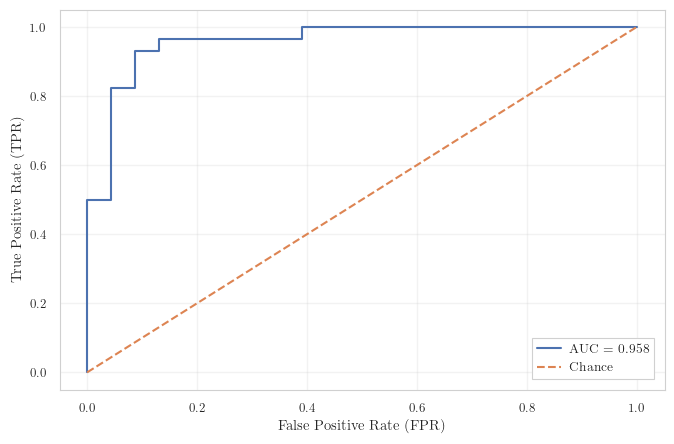

In [35]:
# =============================
# SVM CHECK — train/test on final FS CpGs + ROC plot (thesis style)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, classification_report,
    average_precision_score, matthews_corrcoef, roc_curve
)

print("\n" + "=" * 90)
print("SVM CHECK — final FS CpGs | train/test (no leakage) + ROC")
print("=" * 90)

# -----------------------------
# REQUIRED INPUTS (must exist)
# -----------------------------
#   M_train, M_test               : post-Edgar + beta->M + (optional) variance filter
#   y_train, y_test
#   cpg_cols_current              : columns aligned to M_train/M_test
#   final_cpgs                    : final selected CpGs (e.g., K=5000) from your FS pipeline
#   SVM_C, SVM_MAX_ITER, RANDOM_STATE
#   apply_thesis_style, place_legend
#
# Optional:
#   DATASET_NAME (string) e.g. "GSE225845" for saving plots

DATASET_NAME = globals().get("DATASET_NAME", "GSE225845")  # set explicitly if you want
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Default hyperparameters (if not already defined)
# -----------------------------
SVM_C = globals().get("SVM_C", 1.0)
SVM_MAX_ITER = globals().get("SVM_MAX_ITER", 5000)
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

print(f"SVM_C = {SVM_C}")
print(f"SVM_MAX_ITER = {SVM_MAX_ITER}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

SVM_C = 0.5   # più regolarizzazione → meno overfitting
SVM_MAX_ITER = 10000
RANDOM_STATE = 42


# -----------------------------
# 1) Build matrices on final CpGs (aligned with current M space)
# -----------------------------
if "M_train" not in globals() or "M_test" not in globals():
    raise NameError("Missing M_train/M_test. Use the matrices produced by STEP 2 (post-Edgar + M-transform).")

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all)}

final_cpgs = np.array(final_cpgs, dtype=object)
jj = np.array([col_to_j[c] for c in final_cpgs if c in col_to_j], dtype=int)

if jj.size == 0:
    raise RuntimeError("No final_cpgs found in cpg_cols_current. Check alignment / filtering masks.")

if jj.size != final_cpgs.size:
    missing = [c for c in final_cpgs.tolist() if c not in col_to_j]
    print(f"WARNING: {len(missing)} CpGs missing from current columns. Using {jj.size}/{final_cpgs.size}.")
    final_cpgs = np.array([c for c in final_cpgs.tolist() if c in col_to_j], dtype=object)

X_train = M_train[:, jj].astype(np.float32, copy=False)
X_test  = M_test[:,  jj].astype(np.float32, copy=False)

print(f"Shapes: X_train={X_train.shape} | X_test={X_test.shape}")
print(f"n_features (final) = {X_train.shape[1]:,}")

# -----------------------------
# 2) Linear SVM on M
# -----------------------------
svm = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("svm", LinearSVC(C=SVM_C, class_weight="balanced", max_iter=SVM_MAX_ITER, random_state=RANDOM_STATE)),
])

svm.fit(X_train, y_train)

score = svm.decision_function(X_test)
pred  = svm.predict(X_test)

auc  = roc_auc_score(y_test, score)
bacc = balanced_accuracy_score(y_test, pred)
cm   = confusion_matrix(y_test, pred, labels=[0, 1])

precision = precision_score(y_test, pred, zero_division=0)
recall    = recall_score(y_test, pred, zero_division=0)
f1        = f1_score(y_test, pred, zero_division=0)
pr_auc    = average_precision_score(y_test, score)
mcc       = matthews_corrcoef(y_test, pred)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp + 1e-12)

print("\nMETRICS (test):")
print(f"AUC         = {auc:.4f}")
print(f"BAcc        = {bacc:.4f}")
print(f"Precision   = {precision:.4f}")
print(f"Recall      = {recall:.4f}")
print(f"F1-score    = {f1:.4f}")
print(f"PR-AUC      = {pr_auc:.4f}")
print(f"Specificity = {specificity:.4f}")
print(f"MCC         = {mcc:.4f}")

print("\nConfusion matrix [labels 0,1]:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, pred, digits=4, zero_division=0))

# -----------------------------
# 3) ROC plot (thesis style) + SAVE PDF
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, score)

apply_thesis_style(use_tex=True, legend_position="lower right", legend_outside=False)
fig_roc, ax = plt.subplots(figsize=(6.8, 4.5))

ax.plot(fpr, tpr, label=rf"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")

# no plot title (print to screen instead)
print(f"\nROC — Linear SVM on final FS CpGs (K={X_train.shape[1]:,}) | dataset={DATASET_NAME}")

place_legend(ax)
fig_roc.tight_layout()

pdf_path = OUTDIR / f"{DATASET_NAME}_svmcheck_ROC_finalFS.pdf"
fig_roc.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

# Outputs you may reuse later:
#   svm, fig_roc, score, pred, (auc, bacc, precision, recall, f1, pr_auc, specificity, mcc), cm



FIG — PCA boundary with calibrated probability (train-only fit)

Dataset: GSE225845
SVM_C=0.5 | SVM_MAX_ITER=10000 | RANDOM_STATE=42
Saved plot to: plots_outputs/GSE225845_boundary_pca_prob_calibrated.pdf


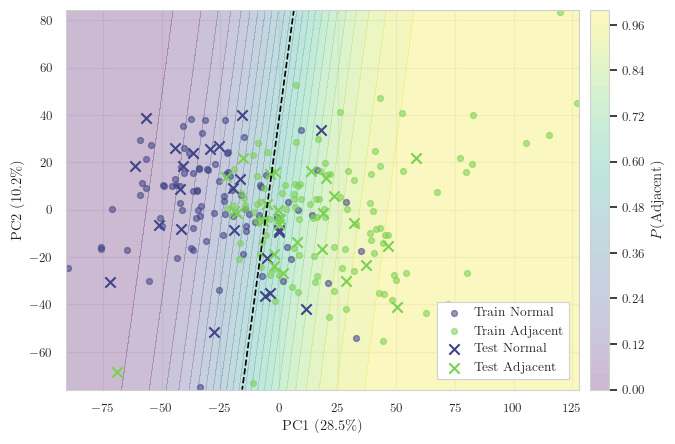

SVM boundary in PCA space | AUC=0.958


In [36]:
# =========================
# FIG — Boundary in PCA space + colorbar (calibrated probability)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.calibration import CalibratedClassifierCV

# -----------------------------
# CHECK REQUIRED MATRICES
# -----------------------------
if "X_train" not in globals() or "X_test" not in globals():
    raise RuntimeError("X_train / X_test not found. Run the SVM CHECK cell first.")

# -----------------------------
# CONFIG
# -----------------------------
DATASET_NAME = "GSE225845"
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

SVM_C = 0.5
SVM_MAX_ITER = 10000
RANDOM_STATE = 42

print("\nFIG — PCA boundary with calibrated probability (train-only fit)\n")
print(f"Dataset: {DATASET_NAME}")
print(f"SVM_C={SVM_C} | SVM_MAX_ITER={SVM_MAX_ITER} | RANDOM_STATE={RANDOM_STATE}")

# -----------------------------
# 1) Fit Linear SVM (train-only)
# -----------------------------
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        C=SVM_C,
        class_weight="balanced",
        max_iter=SVM_MAX_ITER,
        random_state=RANDOM_STATE
    )),
])

svm_pipe.fit(X_train, y_train)

# -----------------------------
# 2) Calibrate (train-only)
# -----------------------------
cal = CalibratedClassifierCV(estimator=svm_pipe, method="sigmoid", cv=3)
cal.fit(X_train, y_train)

# -----------------------------
# 3) PCA (fit ONLY on train)
# -----------------------------
pca_scaler = StandardScaler()
Xtr_std = pca_scaler.fit_transform(X_train)
Xte_std = pca_scaler.transform(X_test)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Ztr = pca.fit_transform(Xtr_std)
Zte = pca.transform(Xte_std)

ve = pca.explained_variance_ratio_

# -----------------------------
# 4) Grid in PCA space
# -----------------------------
Z_all = np.vstack([Ztr, Zte])
x_min, x_max = Z_all[:,0].min()-1, Z_all[:,0].max()+1
y_min, y_max = Z_all[:,1].min()-1, Z_all[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 240),
    np.linspace(y_min, y_max, 240)
)

grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_std = pca.inverse_transform(grid_pca)
grid_orig = pca_scaler.inverse_transform(grid_std)

zz = cal.predict_proba(grid_orig)[:,1].reshape(xx.shape)

# -----------------------------
# 5) Plot
# -----------------------------
apply_thesis_style(use_tex=True, legend_position="lower right")

fig, ax = plt.subplots(figsize=(6.8, 4.5))

cf = ax.contourf(xx, yy, zz, levels=25, cmap="viridis", alpha=0.28)
ax.contour(xx, yy, zz, levels=[0.5], colors="black", linestyles="--", linewidths=1.2)

c0 = plt.cm.viridis(0.20)
c1 = plt.cm.viridis(0.80)

ax.scatter(Ztr[y_train==0,0], Ztr[y_train==0,1],
           s=18, alpha=0.55, c=[c0], label="Train Normal")

ax.scatter(Ztr[y_train==1,0], Ztr[y_train==1,1],
           s=18, alpha=0.55, c=[c1], label="Train Adjacent")

ax.scatter(Zte[y_test==0,0], Zte[y_test==0,1],
           s=55, marker="x", c=[c0], label="Test Normal")

ax.scatter(Zte[y_test==1,0], Zte[y_test==1,1],
           s=55, marker="x", c=[c1], label="Test Adjacent")

ax.set_xlabel(rf"$\mathrm{{PC1}}\ ({ve[0]*100:.1f}\%)$")
ax.set_ylabel(rf"$\mathrm{{PC2}}\ ({ve[1]*100:.1f}\%)$")

cbar = fig.colorbar(cf, ax=ax, fraction=0.045, pad=0.02)
cbar.set_label(r"$P(\mathrm{Adjacent})$")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE
# -----------------------------
pdf_path = OUTDIR / f"{DATASET_NAME}_boundary_pca_prob_calibrated.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

print(f"SVM boundary in PCA space | AUC={auc:.3f}")
